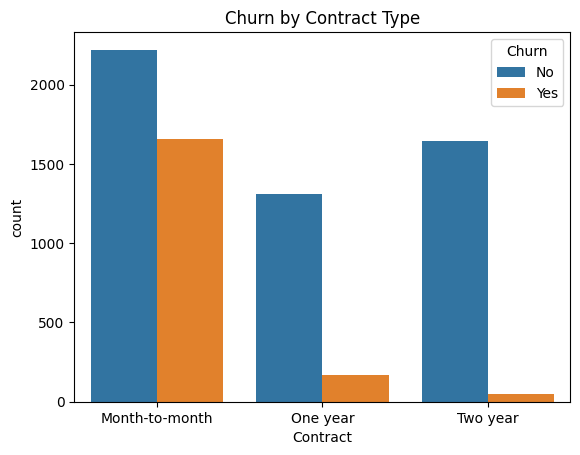

Benchmark (Logistic Regression) F1-Score: 0.5254237288135594
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Random Forest Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Model Evaluation:
Recall: 0.4718498659517426
F1-Score: 0.5587301587301587
AUC-ROC: 0.8473493121616448
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGBoost Model Evaluation:
Recall: 0.5335120643431636
F1-Score: 0.5958083832335329
AUC-ROC: 0.8613558023745691


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score, recall_score

# تحميل البيانات (بافتراض استخدام مجموعة بيانات Telco من Kaggle)
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# معالجة القيم المفقودة في TotalCharges وتحويلها لنوع رقمي
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
import matplotlib.pyplot as plt
import seaborn as sns

# 1. هندسة الميزات (المطلوبة في مقترحك)
df['AverageMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. رسم بياني سريع (مطلوب في الـ Rubric)
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()
# ترميز المتغير المستهدف (Churn)
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# تحويل المتغيرات الفئوية إلى أرقام (One-Hot Encoding)
df = pd.get_dummies(df)

# تقسيم البيانات إلى ميزات (X) وهدف (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# تقسيم البيانات إلى تدريب واختبار بنسبة 80/20 كما في المقترح
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# تدريب النموذج المرجعي
benchmark_model = LogisticRegression(max_iter=1000)
benchmark_model.fit(X_train_scaled, y_train)

# التنبؤ والتقييم
y_pred_bench = benchmark_model.predict(X_test_scaled)
print("Benchmark (Logistic Regression) F1-Score:", f1_score(y_test, y_pred_bench))

# 1. تحسين Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

print("\nRandom Forest Best Parameters:", grid_rf.best_params_)
best_rf_model = grid_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_scaled)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Model Evaluation:")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf)}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf)}")

# 2. تحسين XGBoost
xgb_params = {
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 5]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), xgb_params, scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_xgb.fit(X_train_scaled, y_train)

print("\nXGBoost Best Parameters:", grid_xgb.best_params_)
best_xgb_model = grid_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_scaled)
y_prob_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Model Evaluation:")
print(f"Recall: {recall_score(y_test, y_pred_xgb)}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb)}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb)}")